In [1]:
#%%time
import os
import re
import gzip
import math
import random
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

from ast import literal_eval
import warnings
# 忽略 FutureWarning 类型警告
warnings.simplefilter(action='ignore', category=FutureWarning)
# 忽略特定类型的警告：忽略 scanpy包中含有 ignore 的 UserWarning 类型警告
warnings.filterwarnings("ignore", category=UserWarning, module="scanpy")
# 禁用 pandas 包中的 SettingWithCopyWarning 类型警告  
pd.options.mode.chained_assignment = None  # 或 'raise' 表示引发异常

import inferECC
from inferECC import *

species value: hg38
species == 'mm10':  False


In [2]:
### fig1、fig2 high cell ratio

In [4]:
df = pd.read_csv(f"D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/01.stat/f01-df_cancer_sample_cpr.xls", sep='\t', index_col=0)
df

,cancer,sample,cpr,chr_100k,n_cells,pos_cell_frequency,pos_cell_number,min_cov_in_sample,max_cov_in_sample,mean_cov_in_sample,median_cov_in_sample,std_cov_in_sample
chr10:10000000_10100000,BRCA,ht029b1-s1pc,chr10:10000000_10100000,chr10:10000000_10100000,3.0,0.000881,3.0,0.0,6.404285,0.004790,0.0,0.163846
chr10:1000000_1100000,BRCA,ht029b1-s1pc,chr10:1000000_1100000,chr10:1000000_1100000,215.0,0.063161,215.0,0.0,34.568285,0.211530,0.0,1.187001
chr10:100000_200000,BRCA,ht029b1-s1pc,chr10:100000_200000,chr10:100000_200000,18.0,0.005288,18.0,0.0,13.404279,0.020306,0.0,0.339140
chr10:100100000_100200000,BRCA,ht029b1-s1pc,chr10:100100000_100200000,chr10:100100000_100200000,3.0,0.000881,3.0,0.0,2.917205,0.002386,0.0,0.080737
chr10:100300000_100400000,BRCA,ht029b1-s1pc,chr10:100300000_100400000,chr10:100300000_100400000,5.0,0.001469,5.0,0.0,8.600553,0.005628,0.0,0.175129
...,...,...,...,...,...,...,...,...,...,...,...,...
chrX:153900000_154000000,UCEC,cpt704du-t1,chrX:153900000_154000000,chrX:153900000_154000000,5.0,0.016234,5.0,0.0,6.775878,0.048258,0.0,0.457961
chrX:154300000_154400000,UCEC,cpt704du-t1,chrX:154300000_154400000,chrX:154300000_154400000,3.0,0.009740,3.0,0.0,3.802548,0.021558,0.0,0.264083
chrX:154400000_154500000,UCEC,cpt704du-t1,chrX:154400000_154500000,chrX:154400000_154500000,5.0,0.016234,5.0,0.0,7.998621,0.060405,0.0,0.591944
chrX:49100000_49200000,UCEC,cpt704du-t1,chrX:49100000_49200000,chrX:49100000_49200000,4.0,0.012987,4.0,0.0,4.725070,0.034395,0.0,0.334653


In [5]:
df_ecdna_wg_ratio = df[["cancer","sample","cpr"]]
df_ecdna_wg_ratio

,cancer,sample,cpr
chr10:10000000_10100000,BRCA,ht029b1-s1pc,chr10:10000000_10100000
chr10:1000000_1100000,BRCA,ht029b1-s1pc,chr10:1000000_1100000
chr10:100000_200000,BRCA,ht029b1-s1pc,chr10:100000_200000
chr10:100100000_100200000,BRCA,ht029b1-s1pc,chr10:100100000_100200000
chr10:100300000_100400000,BRCA,ht029b1-s1pc,chr10:100300000_100400000
...,...,...,...
chrX:153900000_154000000,UCEC,cpt704du-t1,chrX:153900000_154000000
chrX:154300000_154400000,UCEC,cpt704du-t1,chrX:154300000_154400000
chrX:154400000_154500000,UCEC,cpt704du-t1,chrX:154400000_154500000
chrX:49100000_49200000,UCEC,cpt704du-t1,chrX:49100000_49200000


In [ ]:
#按照 cancer、sample 种类对cpr的种类进行统计，得到cpr的数量，计算参考基因组按照100kb分割得到的数量ref_n,用cpr的数量除以ref_n,得到每个 sample 的cpr占比比率ratio
#按照 cancer 种类绘制每个sample的cpr 突变比率的占比数量，每种cancer分组绘图：
#1 画图时，每个分组内部每个sample一个柱状图（每个cancer内部：相同的cancer内部sample的排列顺序按照ratio的从小到大排列）,
#2 柱状图不用显示柱子的两条侧边竖线，只需要显示柱状图的顶部边就可以，这样就得到了一系列的柱状图（在整个大图里面，共用xy轴）,
#3 在每个group（每种cancer就是一个group）内部，画一条本group的ratio的中位数代表的虚线,
#4 图片保存为pdf格式

In [20]:
# -*- coding: utf-8 -*-
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# —— inputs: df with ["cancer","sample","cpr"] ——
CHR_SIZES = {
    "chr1": 248_956_422,"chr2": 242_193_529,"chr3": 198_295_559,"chr4": 190_214_555,
    "chr5": 181_538_259,"chr6": 170_805_979,"chr7": 159_345_973,"chr8": 145_138_636,
    "chr9": 138_394_717,"chr10": 133_797_422,"chr11": 135_086_622,"chr12": 133_275_309,
    "chr13": 114_364_328,"chr14": 107_043_718,"chr15": 101_991_189,"chr16": 90_338_345,
    "chr17": 83_257_441,"chr18": 80_373_285,"chr19": 58_617_616,"chr20": 64_444_167,
    "chr21": 46_709_983,"chr22": 50_818_468,"chrX": 156_040_895,"chrY": 57_227_415
}
BIN = 100_000
ref_n = int(sum(sz // BIN for sz in CHR_SIZES.values()))

# per-sample ratio
tbl = (
    df[["cancer","sample","cpr"]]
    .dropna()
    .drop_duplicates()
    .groupby(["cancer","sample"], as_index=False)["cpr"].nunique()
    .rename(columns={"cpr":"cpr_n"})
)
tbl["ratio"] = tbl["cpr_n"] / ref_n

In [53]:
tbl["ratio"].mean()

0.16160184666739608

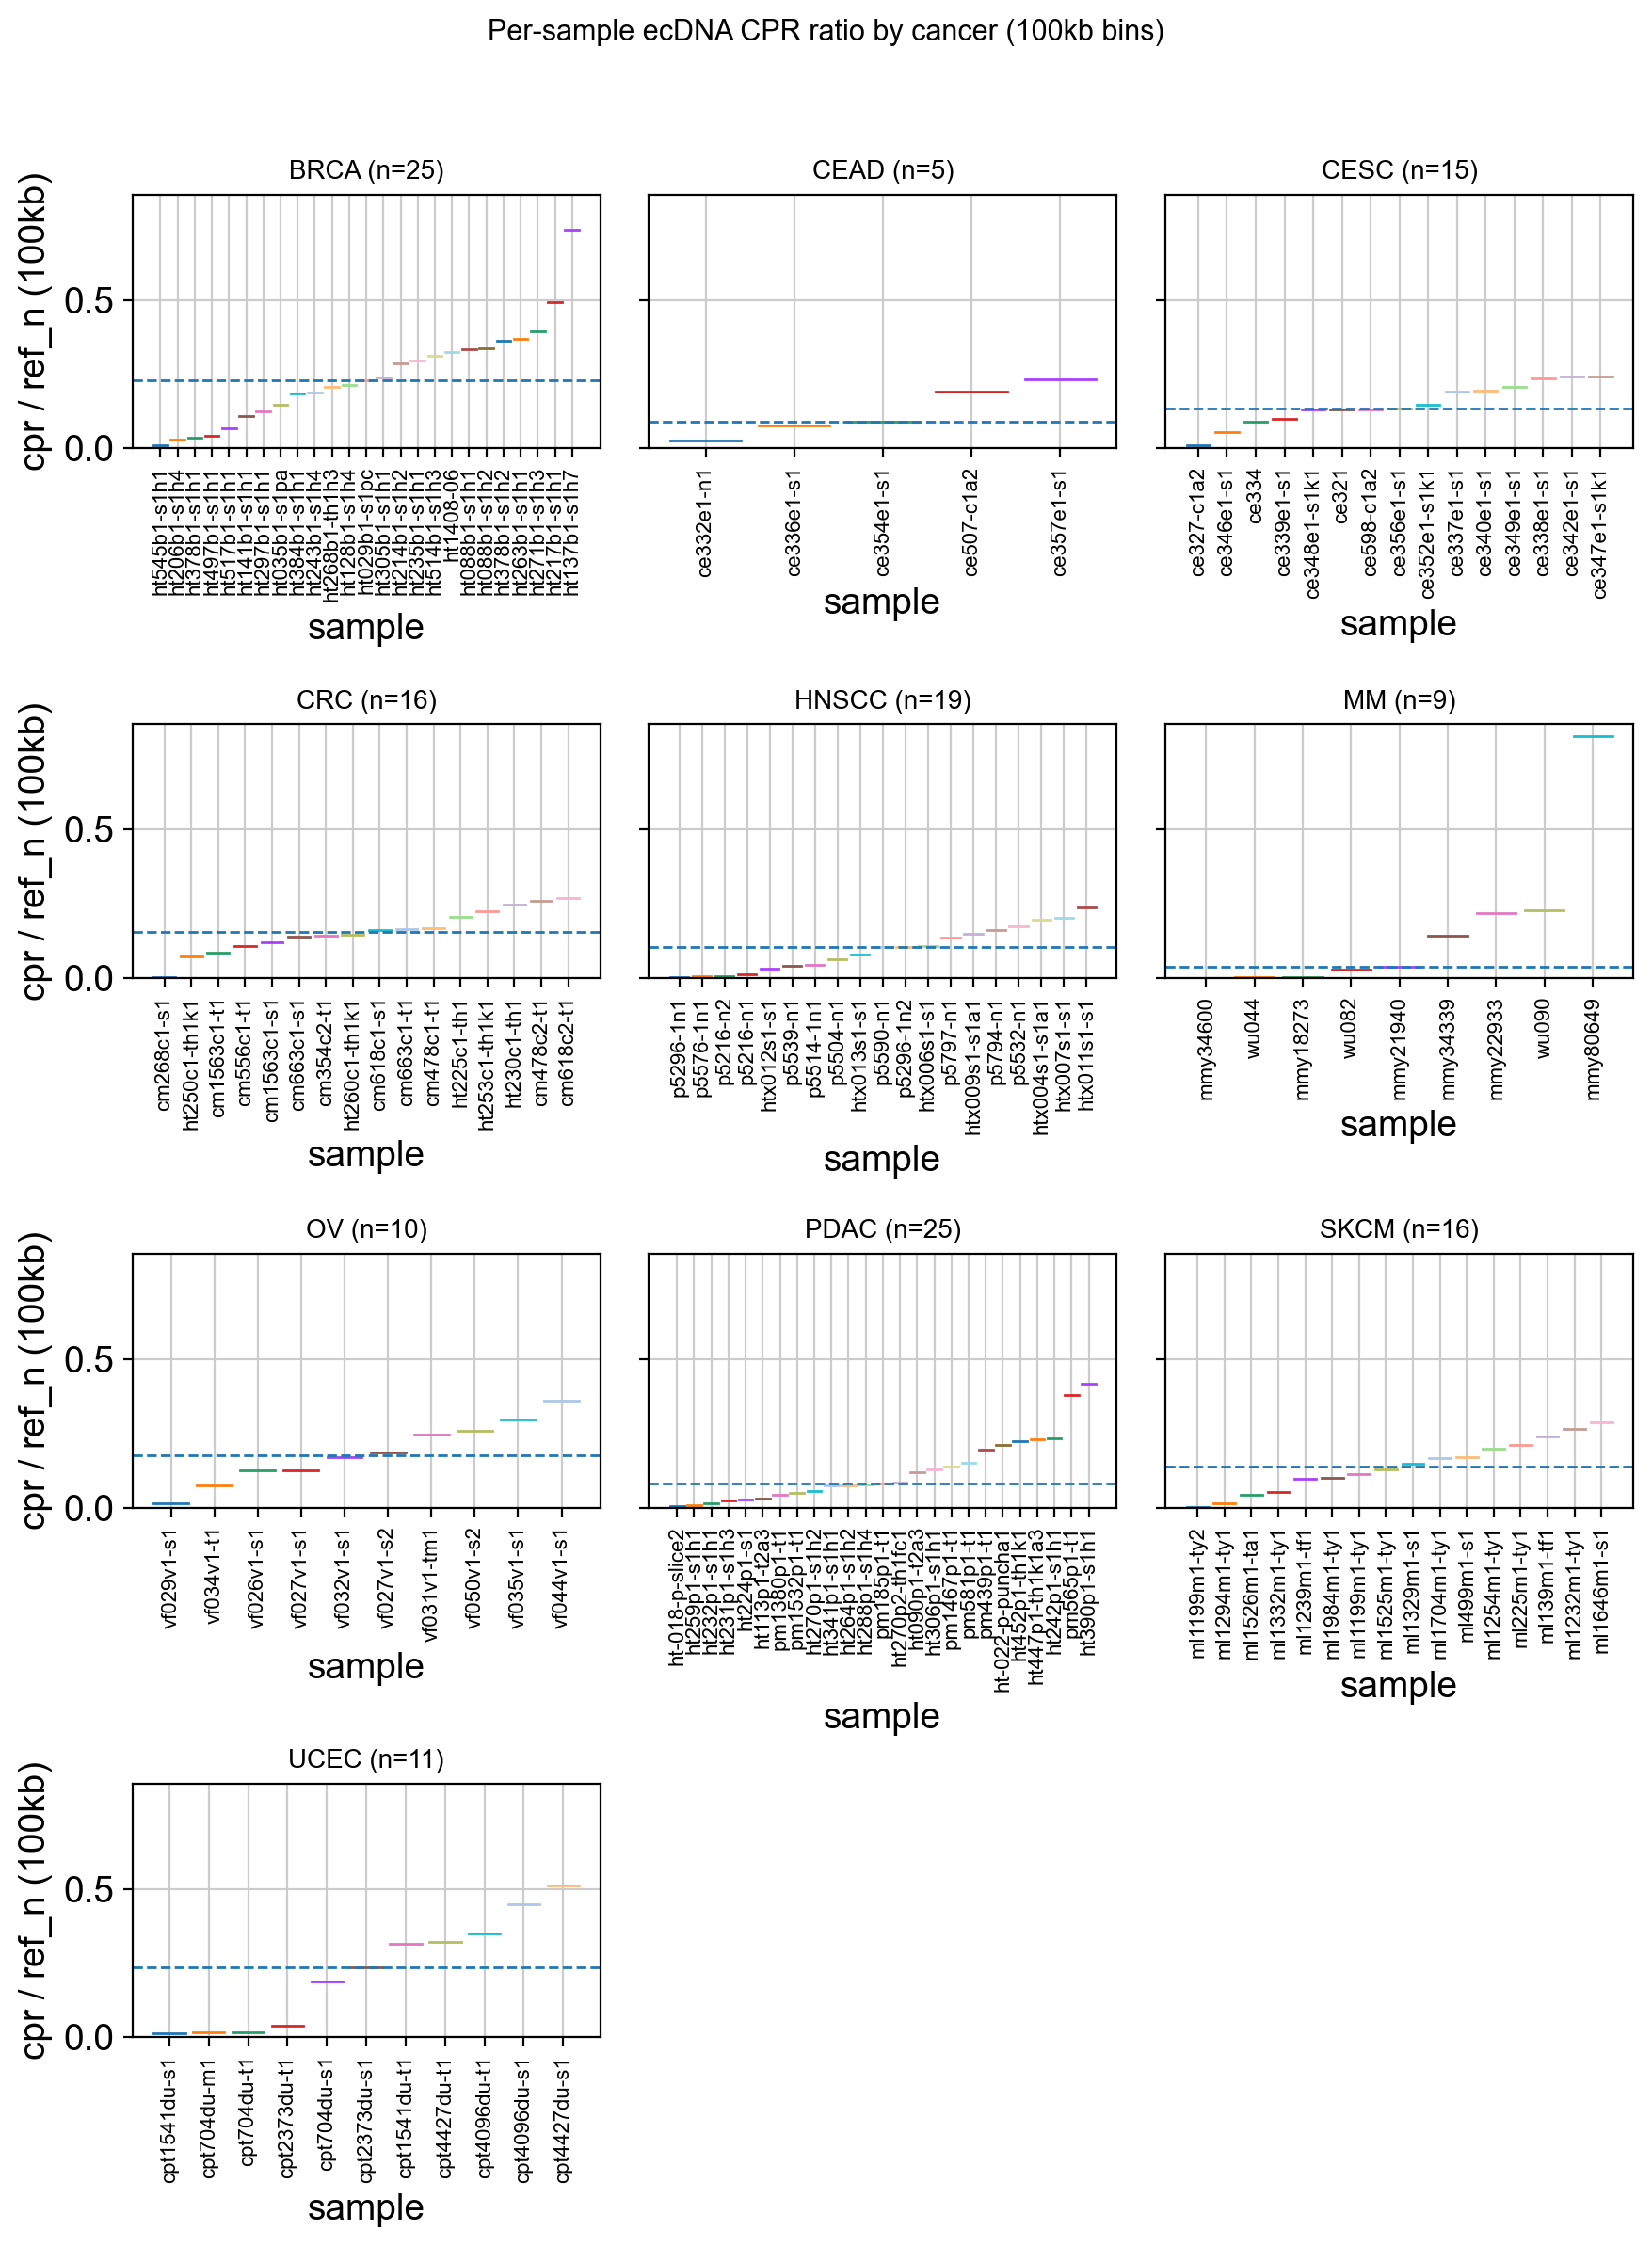

In [36]:
# 3) 分 cancer 作图。每个分组内部：sample 按 ratio 升序；画本组中位数虚线
cancers = tbl["cancer"].unique().tolist()
n = len(cancers)
ncols = 3 if n >= 3 else n
nrows = math.ceil(n / max(ncols,1))

# 版面尺寸随分面数自适应
fig_w = max(6, 3.0 * ncols)
fig_h = max(4, 3.0 * nrows)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), sharey=True)
if nrows*ncols == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = np.array([axes])
axes = axes.flatten()

for i, cancer in enumerate(cancers):
    ax = axes[i]
    sub = tbl.loc[tbl["cancer"] == cancer].sort_values("ratio", ascending=True).reset_index(drop=True)
    x = np.arange(len(sub))
    # 柱：无边框，仅顶部线段；面保留以便直观显示高度（若需空心柱，将 color=None, edgecolor=None, alpha=1）
    bars = ax.bar(x, sub["ratio"].values, width=0.8, linewidth=0, edgecolor=None, alpha=0)

    # 仅画“顶部边”：为每根柱在顶端画一条水平线段
    for xi, h in zip(x, sub["ratio"].values):
        ax.plot([xi-0.4, xi+0.4], [h, h], linewidth=1)

    # 组内中位数虚线
    med = float(sub["ratio"].median())
    ax.axhline(med, linestyle="--", linewidth=1)

    ax.set_title(f"{cancer} (n={len(sub)})", fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["sample"].tolist(), rotation=90, fontsize=8)
    ax.set_xlabel("sample")
    if i % ncols == 0:
        ax.set_ylabel("cpr / ref_n (100kb)")

# 隐藏空白子图
for j in range(i+1, nrows*ncols):
    axes[j].axis("off")

fig.suptitle("Per-sample ecDNA CPR ratio by cancer (100kb bins)", y=0.995, fontsize=11)
fig.tight_layout(rect=[0,0,1,0.98])
plt.savefig("./fig_cpr_rbg_stat_2/13.Fig1-ecDNA_burden/f01-cpr_ratio_by_cancer.pdf", dpi=300)
plt.show()

# 结果表也可导出
tbl.to_csv("./fig_cpr_rbg_stat_2/13.Fig1-ecDNA_burden/f00-cpr_ratio_per_sample.tsv", sep="\t", index=False)

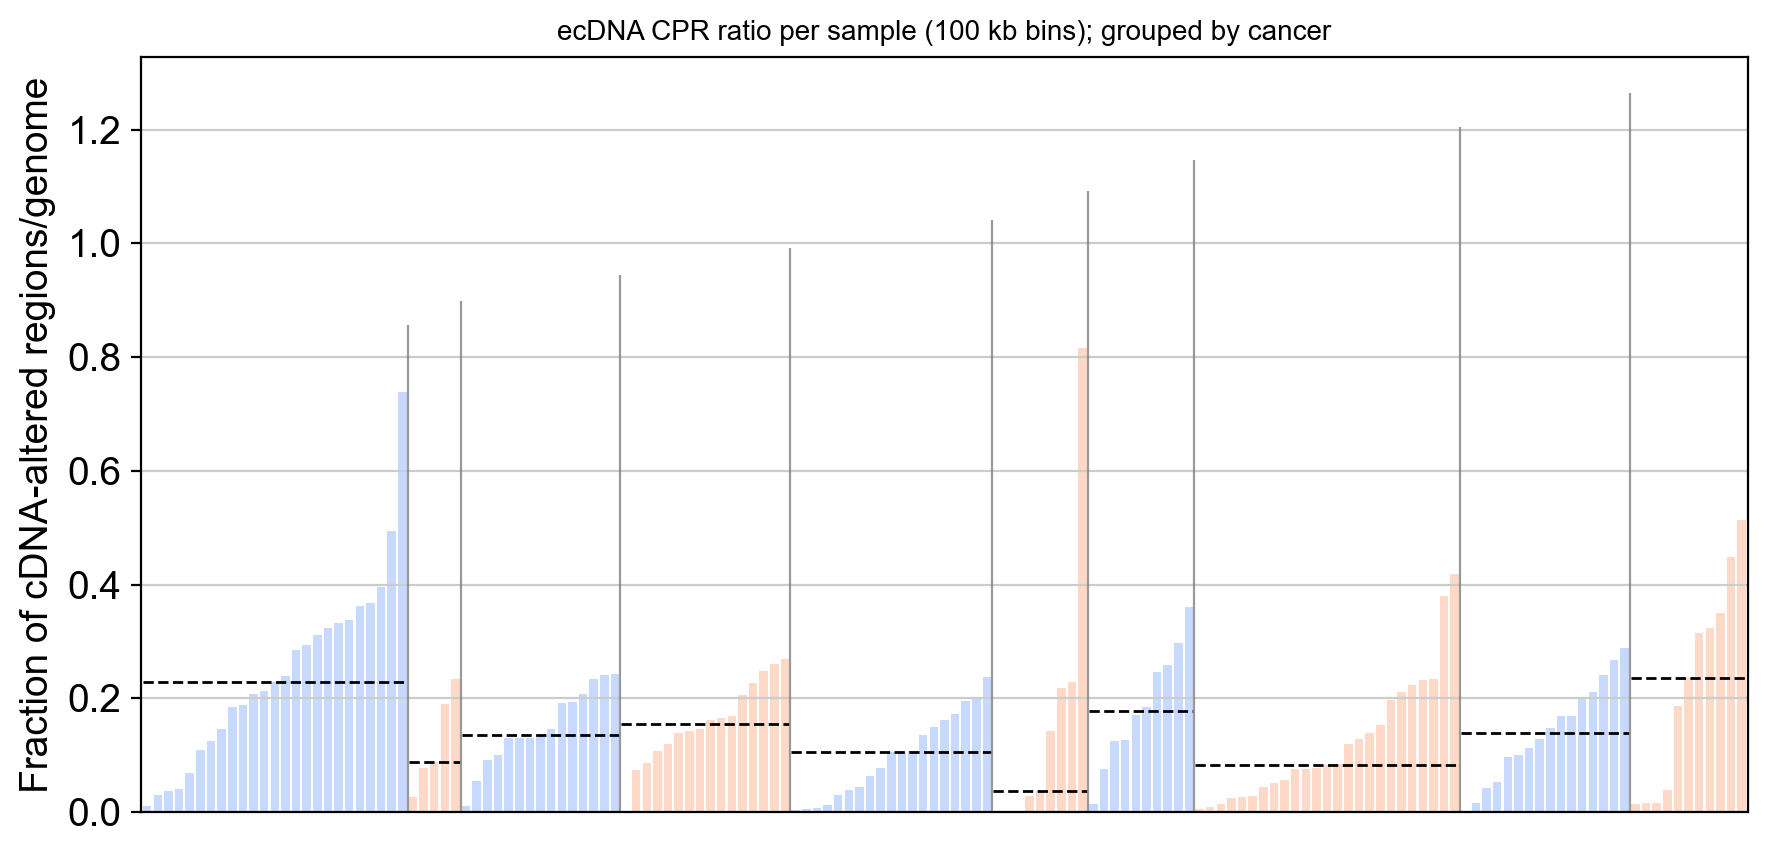

In [37]:
# order within each cancer by ratio asc
cancer_order = tbl["cancer"].drop_duplicates().tolist()
ordered = []
group_ranges = {}  # cancer -> (start_idx, end_idx)
pos = 0
for k in cancer_order:
    sub = tbl.loc[tbl["cancer"] == k].sort_values("ratio", ascending=True).reset_index(drop=True)
    n = len(sub)
    sub = sub.assign(x=np.arange(pos, pos+n))
    ordered.append(sub)
    group_ranges[k] = (pos, pos+n-1)
    pos += n  # no blank slots; separators drawn as vlines

plot_df = pd.concat(ordered, ignore_index=True)

# plot (single shared x-axis)
plt.figure(figsize=(max(8, pos*0.06), 4.5))
ax = plt.gca()

# alternate facecolors per group for visual grouping; no bar edge
colors = ["#c7d9ff", "#ffd9c7"]  # two pale tones; adjust if needed
for i, k in enumerate(cancer_order):
    s, e = group_ranges[k]
    mask = (plot_df["x"] >= s) & (plot_df["x"] <= e)
    face = colors[i % len(colors)]
    bars = ax.bar(
        plot_df.loc[mask, "x"].values,
        plot_df.loc[mask, "ratio"].values,
        width=0.8, linewidth=0, edgecolor=None, color=face
    )
    # top-only edges
    for xi, h in zip(plot_df.loc[mask, "x"].values, plot_df.loc[mask, "ratio"].values):
        ax.plot([xi-0.4, xi+0.4], [h, h], linewidth=1, color="black", alpha=0)

    # group median dashed line limited to group span
    med = float(plot_df.loc[mask, "ratio"].median())
    ax.hlines(med, s-0.4, e+0.4, linestyles="--", linewidth=1, colors="black")

# vertical separators between groups
seps = []
run = 0
for k in cancer_order[:-1]:
    s, e = group_ranges[k]
    xsep = e + 0.5
    seps.append(xsep)
    ax.vlines(xsep, ymin=0, ymax=ax.get_ylim()[1], colors="gray", linewidth=0.8, alpha=0.8)

# axis formatting
ax.set_xlim(-0.6, pos-0.4)
ax.set_xlabel(None)
ax.set_xticks([])                  # 1) hide sample labels
ax.tick_params(axis="x", length=0)
ax.set_ylabel("Fraction of cDNA-altered regions/genome")  # 3)

# optional: annotate group names centered above x-axis ticks (kept off per requirement)
# If later needed, compute centers and place text.

ax.set_title("ecDNA CPR ratio per sample (100 kb bins); grouped by cancer", fontsize=10)
plt.tight_layout()
plt.savefig("./fig_cpr_rbg_stat_2/13.Fig1-ecDNA_burden/f02-cpr_ratio_all_cancers_shared_x.pdf", dpi=300)
plt.show()

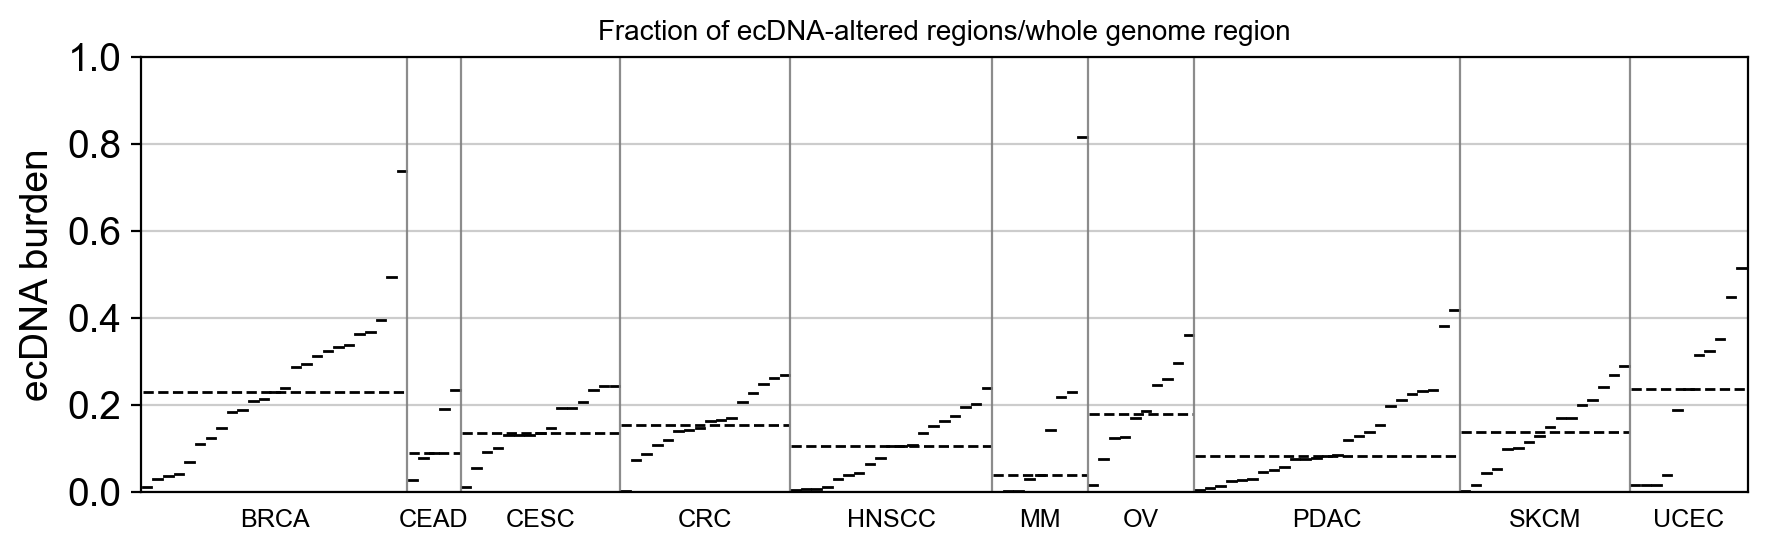

In [38]:
# —— assumes tbl with columns: ["cancer","sample","cpr_n","ratio"] 已算好 ——
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) 排序并拼接到同一 x 轴
cancer_order = tbl["cancer"].drop_duplicates().tolist()
ordered, group_ranges, pos = [], {}, 0
for k in cancer_order:
    sub = tbl.loc[tbl["cancer"] == k].sort_values("ratio").reset_index(drop=True)
    n = len(sub)
    sub = sub.assign(x=np.arange(pos, pos + n))
    ordered.append(sub)
    group_ranges[k] = (pos, pos + n - 1)
    pos += n
plot_df = pd.concat(ordered, ignore_index=True)

# 2) 画图（共享 x 轴）
plt.figure(figsize=(max(8, pos * 0.06), 3))
ax = plt.gca()

# 空心柱：facealpha=0；仅绘制顶部线段
for k in cancer_order:
    s, e = group_ranges[k]
    mask = (plot_df["x"] >= s) & (plot_df["x"] <= e)
    x = plot_df.loc[mask, "x"].to_numpy()
    y = plot_df.loc[mask, "ratio"].to_numpy()

    # 柱体（透明以便空心效果）
    ax.bar(x, y, width=0.8, linewidth=0, edgecolor=None, color="black", alpha=0)

    # 顶部边线（top-only）
    for xi, hi in zip(x, y):
        ax.plot([xi - 0.4, xi + 0.4], [hi, hi], linewidth=1, color="black")

    # 组内中位数虚线（限制在该组范围）
    med = float(np.median(y)) if len(y) else np.nan
    if np.isfinite(med):
        ax.hlines(med, s - 0.4, e + 0.4, linestyles="--", linewidth=1, colors="black")

# 3) 组间分隔竖线（统一高度 0→1）
ax.set_ylim(0, 1)  # y 轴固定 0–1
for k in cancer_order[:-1]:
    s, e = group_ranges[k]
    xsep = e + 0.5
    ax.vlines(xsep, ymin=0, ymax=1, colors="gray", linewidth=0.8, alpha=0.9)

# 4) 在各组 x 区间下方标注 cancer 名称
# 使用 x 轴坐标变换，将文本放在轴下方一点点
xtrans = ax.get_xaxis_transform()  # x 数据坐标，y 轴坐标为轴坐标系
for k in cancer_order:
    s, e = group_ranges[k]
    xc = (s + e) / 2.0
    ax.text(xc, -0.04, k, ha="center", va="top", fontsize=9, transform=xtrans, clip_on=False)

# 轴样式
ax.set_xlim(-0.6, pos - 0.4)
ax.set_xticks([])                       # 隐藏 sample 标签
ax.tick_params(axis="x", length=0)
ax.set_ylabel("ecDNA burden")
ax.set_title("Fraction of ecDNA-altered regions/whole genome region", fontsize=10)

plt.tight_layout()
plt.savefig("./fig_cpr_rbg_stat_2/13.Fig1-ecDNA_burden/f03-cpr_ratio_all_cancers_shared_x.pdf", dpi=300)
plt.show()


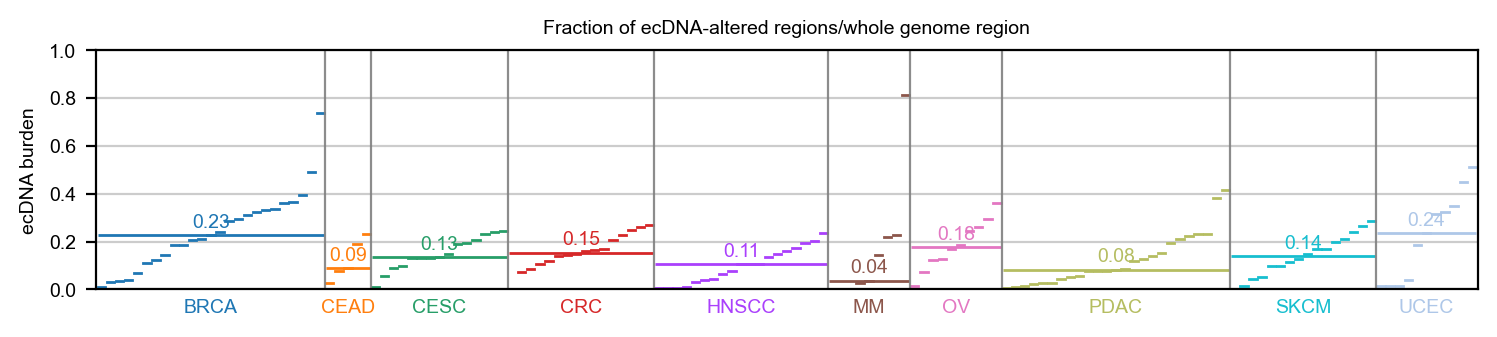

In [51]:
# —— assumes tbl: ["cancer","sample","cpr_n","ratio"] ——
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 字号参数（可按需改）
Y_TICK_SIZE = 7          # y轴刻度字号
Y_LABEL_SIZE = 7         # y轴标题字号
TITLE_SIZE   = 7         # 图题字号
MEDIAN_SIZE  = 7         # 中位数数值标注字号
GROUP_NAME_SIZE = 7      # 分组名称字号

# 统一字体
plt.rcParams.update({"font.family": "Arial", "font.size": 7})

# 1) 排序并拼接到同一 x 轴
cancer_order = tbl["cancer"].drop_duplicates().tolist()
ordered, group_ranges, pos = [], {}, 0
for k in cancer_order:
    sub = tbl.loc[tbl["cancer"] == k].sort_values("ratio").reset_index(drop=True)
    n = len(sub)
    sub = sub.assign(x=np.arange(pos, pos + n))
    ordered.append(sub)
    group_ranges[k] = (pos, pos + n - 1)
    pos += n
plot_df = pd.concat(ordered, ignore_index=True)

# 颜色映射
palette = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_map = {k: palette[i % len(palette)] for i, k in enumerate(cancer_order)}

# 2) 画图
#plt.figure(figsize=(max(8, pos * 0.06), 2))
plt.figure(figsize=(7.5, 1.7))
ax = plt.gca()

for k in cancer_order:
    s, e = group_ranges[k]
    mask = (plot_df["x"] >= s) & (plot_df["x"] <= e)
    x = plot_df.loc[mask, "x"].to_numpy()
    y = plot_df.loc[mask, "ratio"].to_numpy()
    c = color_map[k]

    # 空心柱
    ax.bar(x, y, width=0.8, linewidth=0, edgecolor=None, color=c, alpha=0)

    # 顶部线
    for xi, hi in zip(x, y):
        ax.plot([xi - 0.4, xi + 0.4], [hi, hi], linewidth=1, color=c)

    # 组内中位数实线 + 数值标注
    if len(y):
        med = float(np.median(y))
        ax.hlines(med, s - 0.4, e + 0.4, linestyles="-", linewidth=1, colors=c)
        y_txt = min(0.98, med + 0.015)
        ax.text((s + e) / 2.0, y_txt, f"{med:.2f}",
                ha="center", va="bottom", color=c, fontsize=MEDIAN_SIZE)

# 组间分隔竖线（0→1）
ax.set_ylim(0, 1)
for k in cancer_order[:-1]:
    s, e = group_ranges[k]
    ax.vlines(e + 0.5, ymin=0, ymax=1, colors="gray", linewidth=0.8, alpha=0.9)

# 分组名称（x轴下方）
xtrans = ax.get_xaxis_transform()
for k in cancer_order:
    s, e = group_ranges[k]
    ax.text((s + e) / 2.0, -0.04, k, ha="center", va="top",
            fontsize=GROUP_NAME_SIZE, transform=xtrans, clip_on=False, color=color_map[k])

# 轴样式与刻度字号
ax.set_xlim(-0.6, pos - 0.4)
ax.set_xticks([])
ax.tick_params(axis="x", length=0)
ax.set_yticks(np.arange(0.0, 1.01, 0.2))
ax.tick_params(axis="y", labelsize=Y_TICK_SIZE)

# 轴标题与图题字号
ax.set_ylabel("ecDNA burden", fontsize=Y_LABEL_SIZE)
ax.set_title("Fraction of ecDNA-altered regions/whole genome region", fontsize=TITLE_SIZE)

plt.tight_layout()
plt.savefig("./fig_cpr_rbg_stat_2/13.Fig1-ecDNA_burden/f04-cpr_ratio_all_cancers_shared_x.pdf", dpi=300)
plt.show()
